# IFN680 Project 6: The Sharpness Quest - cVAE_Baseline

**Group 4** - Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

This notebook is **Task 1**. It trains the conditional variational autoencoder (cVAE) of Tutorial 8.3 on `mnist_custom.pt` with **7 latent dimensions**, and it is the baseline that `cVAE_DiscriminatorLoss.ipynb` is compared against.

The model, the loss and the optimiser are the tutorial's. What differs:

| | Tutorial 8.3 | This notebook | Why |
|---|---|---|---|
| Image size | 28 x 28 | 20 x 20 | `mnist_custom.pt` is MNIST resized to 20 x 20 and inverted |
| Last encoder kernel, first decoder kernel | 4 x 4 | 3 x 3 | a 4 x 4 kernel does not fit the 3 x 3 map it meets at 20 x 20 (section 3) |
| Latent size | 8 | 7 | the brief |
| Learning rate | constant 0.001 for 50 epochs | from 0.001 down to 0 along a cosine, over 150 epochs | at a constant rate the loss was still falling well past 50 epochs, so training would not settle (section 4.4) |
| Split scored every epoch | the test split | a development split of the training images | the test split is kept for `main_report.ipynb` (section 2.2) |
| Final model | the model after one run | retrained on all 60,000 training images, once per seed 0, 1, 2 | section 6 |

It writes `cVAE_Baseline.pth` (the weights of each seed), `cVAE_Baseline_history.json` (every training curve) and `mnist_custom_test.pt` (the test split).

**Sections:** 1 Setup, 2 The data, 3 The model, 4 Training, 5 Development run and convergence, 6 The final models, 7 Samples.

## 1 Setup

The libraries, the device and the seed. The printed versions make the executed notebook its own
record of where it ran. The palette cell below it keeps every figure in the same colours.

In [1]:
# The Week 8 tutorial's stack. json carries results from the training notebooks to
# main_report.ipynb, and make_grid lays out digit grids the way the tutorial's figures do.
import json
import os
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid

# The brief asks for the IFN680 GPU environment. The same code runs on a CPU when no GPU is
# visible, so the notebook runs anywhere and every tensor is placed with .to(device).
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"device      : {device}")
print(f"python      : {platform.python_version()}")
print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"numpy       : {np.__version__}")

# One seed for everything: the data split, the initial weights and every random draw.
SEED = 0
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

device      : cuda:0
python      : 3.12.14
torch       : 2.13.0+cu126
torchvision : 0.28.0+cu126
numpy       : 2.5.3


In [2]:
# One palette for every figure in the project, so the figures read as a set.
INK, ACCENT, WARM = "#1f2933", "#2f6f9f", "#c1553b"
MUTED, PALE, GREEN = "#7b8794", "#e8ecf1", "#3f7d58"
plt.rcParams.update({"font.size": 8, "axes.titlesize": 8, "axes.edgecolor": MUTED,
                     "axes.spines.top": False, "axes.spines.right": False})

## 2 The data

`mnist_custom.pt` holds four tensors: 60,000 training images with their labels, and 10,000 test
images with theirs. The cell below loads it. Because `main_report.ipynb` needs the test split and
nothing else, the cell also writes that split to its own file, `mnist_custom_test.pt`, so the
archive does not have to carry the whole 112 MB dataset.

In [3]:
# mnist_custom.pt is the dataset supplied with the brief: MNIST resized to 20 x 20 and
# inverted. weights_only=True loads the tensors and refuses to run any code stored in the file.
data = torch.load("mnist_custom.pt", weights_only=True)
train_images, train_labels = data["train_images"], data["train_labels"]

# main_report.ipynb needs the test split and nothing else, so it is written to its own file
# here. No training notebook scores it or makes a prediction on it.
if not os.path.exists("mnist_custom_test.pt"):
    test_split = {key: data[key] for key in ("test_images", "test_labels")}
    torch.save(test_split, "mnist_custom_test.pt")
print(f"loaded mnist_custom.pt: {', '.join(data.keys())}")

loaded mnist_custom.pt: train_images, train_labels, test_images, test_labels


### 2.1 What the file holds

The brief calls the data only "the modified MNIST dataset", so its properties are measured before
anything is trained on it. Two of them matter later. The images are **20 x 20**, not the
tutorial's 28 x 28, which is why the tutorial's model needs a change (section 3). And the
background is **white** (pixel value 1.0) with dark strokes, the reverse of the tutorial's MNIST.

In [4]:
# What the file actually holds, measured before anything is trained on it.
border = torch.cat([train_images[..., 0, :], train_images[..., -1, :],
                    train_images[..., :, 0], train_images[..., :, -1]], dim=-1)
print(f"train_images : {tuple(train_images.shape)}, {train_images.dtype}")
print(f"train_labels : {tuple(train_labels.shape)}, {train_labels.dtype}")
print(f"pixel range  : {train_images.min():.3f} to {train_images.max():.3f}")
print(f"class counts : {torch.bincount(train_labels, minlength=10).tolist()}")
# The background is white (1.0) and the strokes dark: the reverse of the tutorial's MNIST.
print(f"pixels exactly 1.0 : {(train_images == 1).float().mean():.3f}")
print(f"mean border pixel  : {border.mean():.4f}")

train_images : (60000, 1, 20, 20), torch.float32
train_labels : (60000,), torch.int64
pixel range  : 0.000 to 1.000
class counts : [5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]
pixels exactly 1.0 : 0.701
mean border pixel  : 0.9993


One training image per class, and a histogram of every pixel value in the training set. Almost every pixel is either pure white or near black. A blurred digit has many pixels in between, so blur is easy to see in this data, and easy to measure.

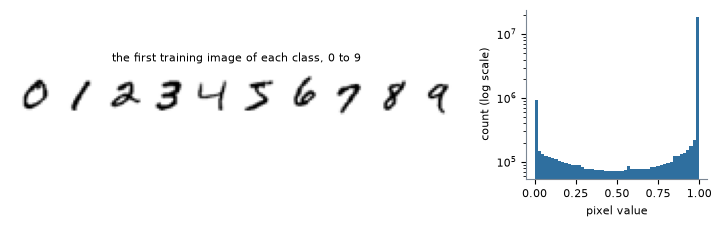

In [5]:
# One training image per class, and every pixel value in the training set. Almost every pixel
# is pure white or near black, so a blurred digit, full of in-between greys, is easy to spot.
first_of_class = [int((train_labels == c).nonzero()[0]) for c in range(10)]
fig, (ax_digits, ax_hist) = plt.subplots(1, 2, figsize=(9, 2.2),
                                         gridspec_kw={"width_ratios": [3, 1.2]})
panel = make_grid(train_images[first_of_class], nrow=10, pad_value=1)
ax_digits.imshow(panel[0], cmap="gray", vmin=0, vmax=1)
ax_digits.set_title("the first training image of each class, 0 to 9")
ax_digits.axis("off")
ax_hist.hist(train_images.flatten().numpy(), bins=50, color=ACCENT, log=True)
ax_hist.set_xlabel("pixel value")
ax_hist.set_ylabel("count (log scale)")
plt.show()

### 2.2 A development split

Choosing settings and deciding when training has finished both need images the model is not
trained on. Using the test images for that would make them part of the training process, and
their score would stop being an honest measure of new data. So a **development split** is held
out from the training images, drawn at random with the seed:

| Split | Images | Used for |
|---|---|---|
| fit | 50,000 | training during development runs |
| development | 10,000 | curves, the convergence check, and choosing settings |
| all training images | 60,000 | the final models, retrained once the settings are fixed |
| test | 10,000 | `main_report.ipynb` only |

The draw is random because the MNIST files keep the order their images were assembled in. Its
documentation (LeCun, Cortes and Burges) says the test file's first 5,000 images are cleaner and
easier than its last 5,000, and that in one of its two source collections each writer's digits
appear as one consecutive block. A slice of consecutive images is therefore not guaranteed to
look like the rest.

| Call | What you give it | What you get back |
|---|---|---|
| `torch.Generator().manual_seed(s)` | a seed | a private random-number source, independent of every other draw |
| `torch.randperm(n, generator=g)` | a count and a generator | the numbers 0 to n-1 in a random order |
| `torch.bincount(labels, minlength=10)` | integer labels | how many times each of 0 to 9 occurs |

In [6]:
# The development split: a seeded random draw of N_DEV training images, held out to judge
# convergence and to choose settings. The final models retrain on all N_TOTAL images.
N_TOTAL, N_DEV = 60000, 10000
split_generator = torch.Generator().manual_seed(SEED)
order = torch.randperm(len(train_images), generator=split_generator)[:N_TOTAL]
dev_index, fit_index = order[:N_DEV], order[N_DEV:]
print(f"fit split         : {len(fit_index):,} images")
print(f"development split : {len(dev_index):,} images")
dev_counts = torch.bincount(train_labels[dev_index], minlength=10).tolist()
print(f"development class counts : {dev_counts}")
print(f"refit set (fit + development) : {len(order):,} images")

fit split         : 50,000 images
development split : 10,000 images
development class counts : [953, 1167, 1018, 1066, 967, 921, 920, 1045, 931, 1012]
refit set (fit + development) : 60,000 images


## 3 The model

The tutorial's cVAE. An **encoder** turns an image and its class into a small cloud of possible
codes, described by a centre `mu` and a spread (`logvar`, the log of the variance), in a
7-dimensional **latent space**. A **decoder** turns a code and a class back into an image.
Because the class is given to both, the code only has to carry *how* the digit is written
(slant, thickness, size), and at generation time any class can be asked for.

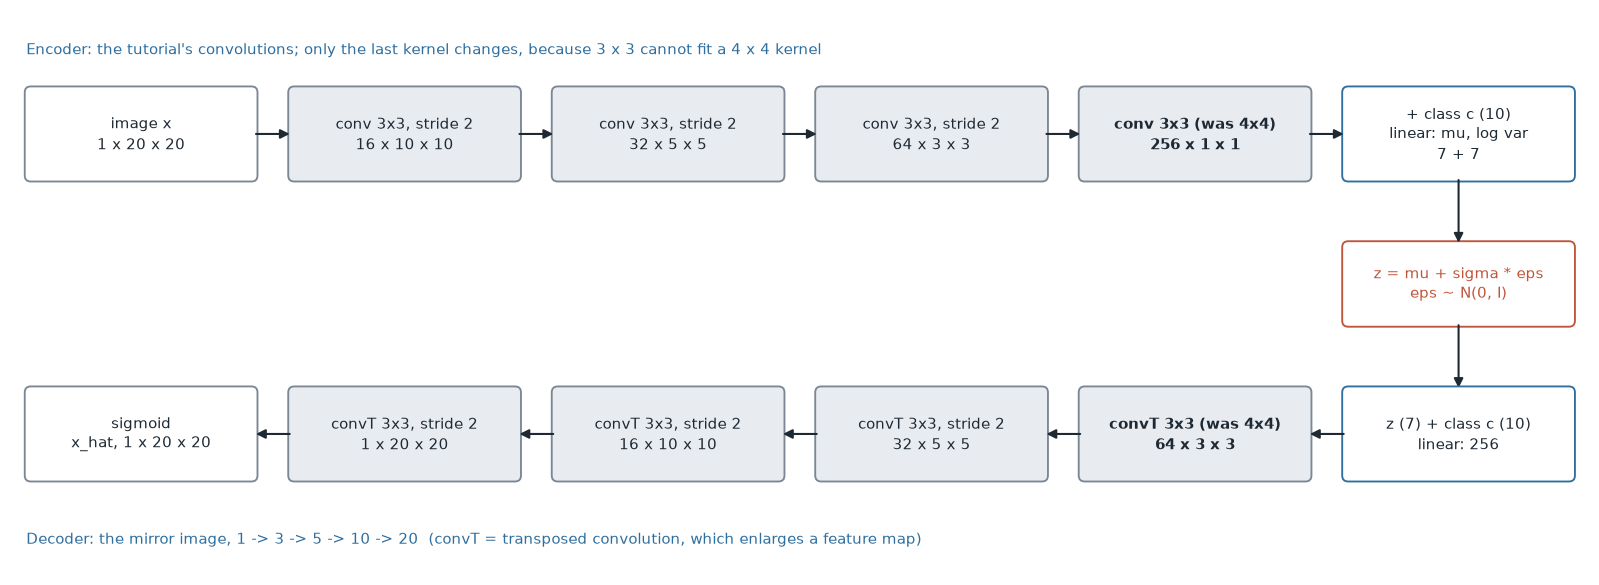

**Why one kernel had to change.** A convolution with kernel size k, stride s and padding p turns
an n x n map into a map of side `floor((n + 2p - k) / s) + 1`. The tutorial's first three layers
(k = 3, s = 2, p = 1) take 20 to 10, 10 to 5, and 5 to `floor((5 + 2 - 3) / 2) + 1 = 3`. Its fourth
layer then has a 4 x 4 kernel and no padding, which is larger than the 3 x 3 map it is given, so
PyTorch stops with an error on the first batch. A 3 x 3 kernel covers the map exactly and gives
the 1 x 1 output the rest of the model expects. The decoder mirrors it.

Padding the images back to 28 x 28 would also run, but it changes the task. The border would add
384 constant white pixels to every image, 49% of the 784, and the decoder reproduces a constant
perfectly. The average pixel error would then roughly halve, and so would its weight against the
KL term, silently changing the balance the tutorial's loss was set up with.

| Call | What you give it | What you get back |
|---|---|---|
| `nn.Conv2d(c_in, c_out, kernel_size, stride, padding)` | maps of shape (batch, c_in, n, n) | (batch, c_out, n', n'): each output value is a weighted sum over a kernel-sized patch of every input map |
| `nn.ReLU()` | any tensor | the same tensor with negative values set to 0 |
| `nn.Flatten()` | (batch, 256, 1, 1) | (batch, 256) |
| `torch.cat([a, b], dim=1)` | two tensors with the same batch size | one tensor with their columns side by side |
| `torch.chunk(x, 2, dim=1)` | (batch, 14) | two tensors of (batch, 7): here `mu` and `logvar` |

In [7]:
# The tutorial's encoder with one change: the last convolution has a 3x3 kernel instead of
# 4x4, because on 20 x 20 images the map entering it is 3 x 3 (20 -> 10 -> 5 -> 3).
class cEncoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cEncoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        # Define the encoder layers
        self.encoder_backbone = nn.Sequential(
            # Layer 1: 1x20x20 -> 16x10x10
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 2: 16x10x10 -> 32x5x5
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 64x3x3
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 4: 64x3x3 -> 256x1x1 (the tutorial's kernel_size=4 fitted its 4x4 map)
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Flatten and project to z_dim
            nn.Flatten(),  # 256*1*1 = 256
        )
        self.encoder_head = nn.Sequential(
            nn.Linear(256 + num_classes, 2 * z_dim)
        )

    def forward(self, x, cond):
        # x shape: (batch_size, 1, 20, 20); cond: (batch_size, num_classes), one-hot
        x = self.encoder_backbone(x)
        x = torch.cat([x, cond], dim=1)
        x = self.encoder_head(x)
        mu, logvar = torch.chunk(x, 2, dim=1)
        return mu, logvar

### 3.1 The decoder

A **transposed convolution** runs the arithmetic backwards: it spreads each input value over a
kernel-sized patch of a larger output. Its output side is
`(n - 1) s - 2p + k + output_padding`, which gives 1 to 3 (k = 3, s = 1, p = 0), then 3 to 5, 5 to
10 and 10 to 20 (k = 3, s = 2, p = 1, with output_padding 0, 1 and 1). The final sigmoid keeps every
pixel between 0 and 1, the range of the data.

| Call | What you give it | What you get back |
|---|---|---|
| `nn.Unflatten(1, (256, 1, 1))` | (batch, 256) | (batch, 256, 1, 1), a 1 x 1 map with 256 channels |
| `nn.ConvTranspose2d(c_in, c_out, kernel_size, stride, padding, output_padding)` | (batch, c_in, n, n) | (batch, c_out, n', n') with n' as above |
| `nn.Sigmoid()` | any tensor | each value squashed into (0, 1) |

In [8]:
# The tutorial's decoder with the mirror-image change: the first transposed convolution has
# a 3x3 kernel, so the maps grow 1 -> 3 -> 5 -> 10 -> 20 and end at the image size.
class cDecoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cDecoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.decoder_input = nn.Sequential(
            # Project latent vector to a feature map
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(),
        )
        self.decoder_backbone = nn.Sequential(
            nn.Unflatten(1, (256, 1, 1)),  # Reshape to (256, 1, 1)
            # Layer 1: 256x1x1 -> 64x3x3 (the tutorial's kernel_size=4 gave 64x4x4)
            nn.ConvTranspose2d(256, 64, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Layer 2: 64x3x3 -> 32x5x5
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 16x10x10
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # Layer 4: 16x10x10 -> 1x20x20
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] for pixel values
        )

    def forward(self, z, cond):
        z = torch.cat([z, cond], dim=1)
        z = self.decoder_input(z)
        x_hat = self.decoder_backbone(z)
        return x_hat

### 3.2 The loss

`compute_loss` is the tutorial's, unchanged, and it is the loss in the brief's figure:

$$\mathcal{L}_{VAE} = 100 \cdot \mathrm{MSE}(x, \hat{x}) + 0.1 \cdot KL\big(q(z \mid x, c) \,\|\, \mathcal{N}(0, I)\big)$$

The first term, the **mean squared error** over all pixels, rewards a reconstruction that matches
the input pixel by pixel. The second, the **Kullback-Leibler divergence**, pulls each image's cloud
of codes toward a standard normal distribution. That is what makes generation possible later: codes
drawn from N(0, I) then land where the decoder has seen real codes during training. The weights 100
and 0.1 are the tutorial's.

In [9]:
# The tutorial's loss, unchanged: 100 x pixel MSE plus beta x KL, with beta = 0.1.
def compute_loss(x, x_hat, mu, logvar, beta=0.1):
    """
    Compute the reconstruction loss for the autoencoder.
    """

    # Reconstruction loss (MSE)
    recon_loss = 100 * F.mse_loss(x_hat, x, reduction='mean')

    # For standard autoencoder, KL divergence is 0
    if beta == 0:
        kl_loss = 0.0
    else:
        kl_loss = torch.mean(-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))

    # Total loss
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

### 3.3 The cVAE and the reparameterisation trick

`forward()` needs a random code `z` from the encoder's cloud, but a random draw has no gradient.
The trick is to draw the randomness separately, `eps ~ N(0, I)`, and compute
`z = mu + sigma * eps`. The randomness is then an input, and the gradient flows through `mu` and
`sigma` as through any other arithmetic. `encode()` and `decode()` expose the two halves, which the
evaluation code uses to rebuild an image from `mu` alone.

In [10]:
# The tutorial's cVAE, unchanged. forward() draws z with the reparameterisation trick, so the
# random draw stays outside the path the gradient has to flow through.
class cVAE(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cVAE, self).__init__()
        self.encoder = cEncoder(z_dim, num_classes)
        self.decoder = cDecoder(z_dim, num_classes)
        self.z_dim = z_dim
        self.num_classes = num_classes

    def encode(self, x, cond):
        return self.encoder(x, cond)

    def decode(self, z, cond):
        return self.decoder(z, cond)

    def forward(self, x, cond):
        mu, logvar = self.encoder(x, cond)
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        z = mu + eps * sigma
        x_recon = self.decoder(z, cond)
        return x_recon, mu, logvar

### 3.4 Settings

The settings every cVAE run in this project shares.

In [11]:
# Settings shared by both cVAE notebooks, so the two runs are comparable by construction.
Z_DIM, NUM_CLASSES = 7, 10  # the brief fixes 7 latent dimensions (the tutorial used 8)
EPOCHS = 150  # the tutorial trains for 50, too few to settle on this data (4.4)
SEEDS = (0, 1, 2)  # the final models are retrained once per seed
# Progress is printed every PRINT_EVERY epochs; convergence compares windows of WINDOW epochs.
PRINT_EVERY, WINDOW = 10, 10

## 4 Training

The tutorial trains in batches of 1,000 images drawn in a shuffled order. `get_batch` is the
tutorial's own helper: it moves a batch to the device and turns each label into a **one-hot**
vector, ten numbers that are all 0 except a 1 at the class. The second cell below runs one forward
pass: the printed shapes confirm the adapted model takes a 1 x 20 x 20 image to a 7-number code
and back to 1 x 20 x 20.

| Call | What you give it | What you get back |
|---|---|---|
| `TensorDataset(images, labels)` | tensors with the same first dimension | a dataset whose item i is (images[i], labels[i]) |
| `DataLoader(dataset, batch_size, shuffle, generator)` | a dataset | an iterable of batches; with a seeded generator the shuffled order is the same every run |
| `F.one_hot(labels, num_classes=10)` | integer labels | (batch, 10) one-hot rows |

In [12]:
# The tutorial's batching, over tensors instead of torchvision's MNIST class. A seeded
# generator fixes the shuffle order, so both cVAEs see the same batches in the same order.
BATCH_SIZE = 1000


def make_loader(index, shuffle, seed=SEED):
    dataset = TensorDataset(train_images[index], train_labels[index])
    order_generator = torch.Generator().manual_seed(seed) if shuffle else None
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0,
                      generator=order_generator)


def get_batch(batch, device, f_train=True, num_classes=10):
    # The tutorial's helper: move a batch to the device and one-hot encode its labels
    x = batch[0].to(device)
    cond = batch[1].to(device)
    cond = F.one_hot(cond, num_classes=num_classes).float()
    return x, cond


fit_dataloader = make_loader(fit_index, shuffle=True)
dev_dataloader = make_loader(dev_index, shuffle=False)
print(f"{len(fit_dataloader)} fit batches and {len(dev_dataloader)} development batches "
      f"of {BATCH_SIZE}")

50 fit batches and 10 development batches of 1000


In [13]:
# One forward pass on a development batch confirms the adapted kernels restore the 20 x 20
# shape end to end, before any training time is spent.
model = cVAE(Z_DIM, num_classes=NUM_CLASSES).to(device)
x, cond = get_batch(next(iter(dev_dataloader)), device)
x_hat, mu, logvar = model(x, cond)
print(f"x {tuple(x.shape)} -> mu {tuple(mu.shape)} -> x_hat {tuple(x_hat.shape)}")
print(f"cVAE parameters: {sum(p.numel() for p in model.parameters()):,}")

x (1000, 1, 20, 20) -> mu (1000, 7) -> x_hat (1000, 1, 20, 20)
cVAE parameters: 350,107


### 4.1 Scoring the development split

After each epoch the model rebuilds the development images from `mu`, the centre of each image's
cloud of codes, and the loss is averaged over all of them. `model.eval()` and `torch.no_grad()` tell
PyTorch no training happens here, so it keeps no record for gradients and the pass is fast.

In [14]:
# The tutorial's evaluation pass, pointed at the development split. As in the tutorial the
# image is rebuilt from mu, the centre of the encoder's distribution, so no random draw is
# involved and the score is repeatable.
def evaluate_loss(model, dataloader):
    model.eval()
    totals, count = np.zeros(3), 0
    with torch.no_grad():
        for batch in dataloader:
            x, cond = get_batch(batch, device, f_train=False)
            mu, logvar = model.encode(x, cond)
            x_hat = model.decode(mu, cond)
            losses = compute_loss(x, x_hat, mu, logvar)
            totals += len(x) * np.array([float(value) for value in losses])
            count += len(x)
    return totals / count  # total, reconstruction, KL

### 4.2 Keeping the curves

Every epoch's losses go into a dictionary that is saved to disk at the end, so `main_report.ipynb`
can draw and check them without training anything. `vae_optimizer` holds the tutorial's AdamW
settings in one place, so both cVAE notebooks use literally the same ones, and
`cosine_schedule` holds the learning-rate schedule of section 4.4.

| Call | What you give it | What you get back |
|---|---|---|
| `optim.AdamW(parameters, lr, eps, betas)` | the model's weights and settings | an optimiser; `.step()` moves every weight a little against its gradient |
| `optimizer.zero_grad()` | nothing | clears the gradients left by the previous batch |
| `loss.backward()` | nothing | computes the gradient of `loss` for every weight |
| `CosineAnnealingLR(optimizer, T_max)` | an optimiser and a run length in epochs | a schedule; each `.step()` lowers the learning rate along half a cosine, reaching 0 after `T_max` steps |

In [15]:
# Bookkeeping for the training curves, which are saved to the history file for main_report.
def new_history(adversarial=False):
    keys = ["train_total", "train_recon", "train_kl", "dev_total", "dev_recon", "dev_kl",
            "seconds", "lr"]
    if adversarial:
        keys += ["train_d_loss", "train_g_loss", "dev_d_accuracy"]
    return {key: [] for key in keys}


def record(history, split, values):
    for name, value in zip(("total", "recon", "kl"), values):
        history[f"{split}_{name}"].append(float(value))


def report_epoch(epoch, nb_epoch, history):
    # One progress line every PRINT_EVERY epochs, plus the first and the last.
    if epoch == 0 or (epoch + 1) % PRINT_EVERY == 0 or epoch + 1 == nb_epoch:
        line = f"epoch {epoch + 1:3d}/{nb_epoch}  train loss {history['train_total'][-1]:.4f}"
        if history["dev_total"]:
            line += f"  dev recon {history['dev_recon'][-1]:.4f}"
        if history.get("dev_d_accuracy"):
            line += f"  D accuracy {history['dev_d_accuracy'][-1]:.3f}"
        print(line + f"  ({history['seconds'][-1]:.1f} s)")


def vae_optimizer(parameters):
    # The tutorial's optimiser settings, held in one place so both cVAEs use exactly these.
    return optim.AdamW(parameters, lr=0.001, eps=1e-5, fused=False, betas=(0.75, 0.99))


def cosine_schedule(optimizer, nb_epoch):
    # The learning rate falls from its starting value to 0 along half a cosine over the run,
    # so the last epochs take ever smaller steps and the weights settle instead of circling.
    return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=nb_epoch)

### 4.3 The training loop

For each batch: draw codes and rebuild the images (`model(x, cond)`), measure the loss, compute the
gradients, and take one optimiser step. After each epoch, score the development split and move
the learning rate one step down its schedule.

In [16]:
# The tutorial's training loop. Changes from it: losses are summed with .item(), which keeps
# the running total out of the gradient graph; the evaluation split is the development split;
# the learning rate follows the cosine schedule; and the progress bars are dropped, because
# they write to stderr.
def training_loop(model, train_dataloader, dev_dataloader, nb_epoch):
    optimizer = vae_optimizer(model.parameters())
    scheduler = cosine_schedule(optimizer, nb_epoch)
    history = new_history()
    for epoch in range(nb_epoch):
        started = time.perf_counter()
        model.train()
        totals, count = np.zeros(3), 0
        for batch in train_dataloader:
            x, cond = get_batch(batch, device, f_train=True)
            optimizer.zero_grad()
            x_hat, mu, logvar = model(x, cond)
            total_loss, recon_loss, kl_loss = compute_loss(x, x_hat, mu, logvar)
            total_loss.backward()
            optimizer.step()
            totals += len(x) * np.array([total_loss.item(), recon_loss.item(), kl_loss.item()])
            count += len(x)
        record(history, "train", totals / count)
        if dev_dataloader is not None:
            record(history, "dev", evaluate_loss(model, dev_dataloader))
        history["seconds"].append(time.perf_counter() - started)
        # The rate this epoch used, then one step down the schedule for the next epoch
        history["lr"].append(optimizer.param_groups[0]["lr"])
        scheduler.step()
        report_epoch(epoch, nb_epoch, history)
    return history

### 4.4 What "converged" means here

The brief asks for training "until convergence". Here that means the development reconstruction
loss has stopped improving: its mean over the last 10 epochs is within 1% of its mean over
the 10 epochs before. A mean over several epochs is used instead of a single epoch because
one epoch's value moves up and down a little by chance.

The tutorial keeps the learning rate constant for 50 epochs. On this data that is not enough:
at a constant rate the development loss was still falling by several percent every ten epochs
long after epoch 50, because every step has the same size and the weights keep moving instead of
settling. So both cVAEs use a **cosine schedule**: the learning rate starts at the tutorial's
0.001 and falls smoothly to 0 over the run, taking large steps early, when there is much to
learn, and ever smaller ones late, so the weights come to rest. Both models use the same
schedule and the same number of epochs, so it favours neither.

In [17]:
# A run has converged when its mean development reconstruction loss over the last WINDOW
# epochs is within 1% of its mean over the WINDOW epochs before them.
def convergence(curve, window):
    last, previous = np.mean(curve[-window:]), np.mean(curve[-2 * window:-window])
    change = (last - previous) / previous
    return {"last_mean": float(last), "previous_mean": float(previous),
            "relative_change": float(change), "within_1pct": bool(abs(change) < 0.01)}

## 5 Development run and convergence

The model trains on the fit split for 150 epochs under the cosine schedule, and the
development split is scored after every epoch.

In [18]:
# Development run: train on the fit split and score the development split after every epoch.
# Seeding before the model is built fixes its initial weights; the other notebook does the same.
_ = torch.manual_seed(SEED)
model = cVAE(Z_DIM, num_classes=NUM_CLASSES).to(device)
dev_history = training_loop(model, fit_dataloader, dev_dataloader, nb_epoch=EPOCHS)

epoch   1/150  train loss 12.1889  dev recon 6.0117  (1.8 s)


epoch  10/150  train loss 3.3436  dev recon 2.7226  (1.9 s)


epoch  20/150  train loss 2.8102  dev recon 1.9862  (1.7 s)


epoch  30/150  train loss 2.6212  dev recon 1.6985  (1.9 s)


epoch  40/150  train loss 2.4938  dev recon 1.4906  (1.9 s)


...

epoch 110/150  train loss 2.2501  dev recon 1.1883  (1.8 s)


epoch 120/150  train loss 2.2433  dev recon 1.1749  (1.8 s)


epoch 130/150  train loss 2.2366  dev recon 1.1679  (1.9 s)


epoch 140/150  train loss 2.2350  dev recon 1.1658  (1.9 s)


epoch 150/150  train loss 2.2339  dev recon 1.1654  (1.8 s)


### 5.1 Has it converged?

The statistic of section 4.4, then the two curves. The fit-split loss is measured on codes drawn at
random from each image's cloud, so it sits above the development loss, which rebuilds from `mu`.
The dashed line is the learning rate: the curves flatten as it approaches 0.

dev reconstruction loss, mean of the last 10 epochs : 1.1656
mean of the 10 epochs before              : 1.1671
relative change -0.0013, within 1%: True


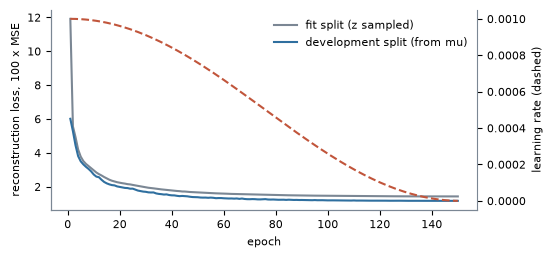

In [19]:
# The convergence statistic of section 4.4, and the curves it summarises.
dev_convergence = convergence(dev_history["dev_recon"], WINDOW)
print(f"dev reconstruction loss, mean of the last {WINDOW} epochs : "
      f"{dev_convergence['last_mean']:.4f}")
print(f"mean of the {WINDOW} epochs before              : {dev_convergence['previous_mean']:.4f}")
print(f"relative change {dev_convergence['relative_change']:+.4f}, "
      f"within 1%: {dev_convergence['within_1pct']}")
epochs = np.arange(1, EPOCHS + 1)
fig, ax = plt.subplots(figsize=(5.5, 2.6))
ax.plot(epochs, dev_history["train_recon"], color=MUTED, label="fit split (z sampled)")
ax.plot(epochs, dev_history["dev_recon"], color=ACCENT, label="development split (from mu)")
ax.set_xlabel("epoch")
ax.set_ylabel("reconstruction loss, 100 x MSE")
ax.legend(frameon=False)
# The learning rate on a second axis: the curves flatten as the schedule approaches 0
twin = ax.twinx()
twin.plot(epochs, dev_history["lr"], color=WARM, linestyle="--")
twin.set_ylabel("learning rate (dashed)")
twin.spines["right"].set_visible(True)
plt.show()

### 5.2 What the reconstructions look like

The helpers below decode images for this notebook and for `main_report.ipynb`: `reconstruct` rebuilds each image from `mu`, and `decode_latents` turns given codes into images of given classes.

In [20]:
# Decoding helpers shared by every notebook that draws digits. Reconstructions decode mu, as
# the tutorial's test pass does; samples decode codes drawn from N(0, I).
def reconstruct(model, images, labels, batch_size=1000):
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            x = images[start:start + batch_size].to(device)
            cond = F.one_hot(labels[start:start + batch_size].to(device), NUM_CLASSES).float()
            mu, _ = model.encode(x, cond)
            outputs.append(model.decode(mu, cond).cpu())
    return torch.cat(outputs)


def decode_latents(model, z, labels, batch_size=1000):
    """Decode latent codes z under classes labels: conditional sampling when z ~ N(0, I)."""
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            cond = F.one_hot(labels[start:start + batch_size].to(device), NUM_CLASSES).float()
            outputs.append(model.decode(z[start:start + batch_size].to(device), cond).cpu())
    return torch.cat(outputs)


def sample_grid(model, z_grid):
    """Rows are the digits 0 to 9 and columns the codes in z_grid, as in the brief's example,
    so each column is one latent code decoded under all ten classes."""
    labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(len(z_grid))
    images = decode_latents(model, z_grid.repeat(NUM_CLASSES, 1), labels)
    return images, labels.cpu()

One development image per class (top row) and its reconstruction (bottom row). These are the images the hypothesis is about, and their blur is what it predicts a discriminator can reduce.

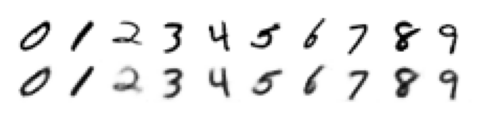

In [21]:
# Development images (top) and their reconstructions (bottom), one per class.
dev_images, dev_labels = train_images[dev_index], train_labels[dev_index]
picks = [int((dev_labels == c).nonzero()[0]) for c in range(10)]
rebuilt = reconstruct(model, dev_images[picks], dev_labels[picks])
panel = make_grid(torch.cat([dev_images[picks], rebuilt]), nrow=10, pad_value=1)
fig, ax = plt.subplots(figsize=(6, 1.5))
ax.imshow(panel[0], cmap="gray", vmin=0, vmax=1)
ax.axis("off")
plt.show()

## 6 The final models

With the settings fixed, the development split has done its job, and the final models retrain on
all training images. Each is trained three times, with seeds 0, 1 and 2, because one run of a
neural network is one draw from many possible runs: a difference between two models is only
convincing if it survives a change of seed.

In [22]:
# Checkpoints are saved from the CPU, so they load on a machine without a GPU.
def cpu_state(module):
    return {name: tensor.detach().cpu().clone() for name, tensor in module.state_dict().items()}

In [23]:
# The final models: the same settings, retrained on all N_TOTAL training images, once per seed.
# Each seed also reshuffles the batches, so the spread across seeds shows how much the result
# depends on the luck of a single run.
refit_loaders = {seed: make_loader(order, shuffle=True, seed=seed) for seed in SEEDS}
checkpoint, refit_histories = {}, {}
for seed in SEEDS:
    print(f"--- seed {seed}")
    _ = torch.manual_seed(seed)
    model = cVAE(Z_DIM, num_classes=NUM_CLASSES).to(device)
    refit_histories[str(seed)] = training_loop(model, refit_loaders[seed], None, EPOCHS)
    checkpoint[f"seed_{seed}"] = cpu_state(model)

--- seed 0


epoch   1/150  train loss 11.1547  (2.1 s)


epoch  10/150  train loss 3.1350  (2.1 s)


epoch  20/150  train loss 2.6925  (2.1 s)


epoch  30/150  train loss 2.5003  (2.0 s)


...

epoch 110/150  train loss 2.2273  (2.0 s)


epoch 120/150  train loss 2.2174  (2.0 s)


epoch 130/150  train loss 2.2126  (2.2 s)


epoch 140/150  train loss 2.2101  (2.1 s)


epoch 150/150  train loss 2.2098  (2.0 s)


### 6.1 A sanity check

A model that learned nothing useful could still return one average image for every input. Its
loss is the bar: each seed's final loss must be well below it.

In [24]:
# Every final model must beat the trivial predictor that answers every image with the mean
# training image. Its loss, 100 x MSE, is the bar each seed's last epoch has to clear.
refit_images = train_images[order]
mean_image = refit_images.mean(dim=0, keepdim=True)
trivial_loss = 100 * F.mse_loss(mean_image.expand_as(refit_images), refit_images).item()
print(f"trivial predictor (mean image): {trivial_loss:.4f}")
for seed, history in refit_histories.items():
    print(f"seed {seed}: last-epoch reconstruction loss {history['train_recon'][-1]:.4f}")
    assert history["train_recon"][-1] < trivial_loss, f"seed {seed} did not learn"

trivial predictor (mean image): 5.6878
seed 0: last-epoch reconstruction loss 1.3916
seed 1: last-epoch reconstruction loss 1.4160
seed 2: last-epoch reconstruction loss 1.4084


### 6.2 Saving

The weights of all three seeds go into one file, and every curve into a JSON file. Both are read by
`main_report.ipynb`, which evaluates the models on the test split.

In [25]:
# The weights (one set per seed) and every curve. main_report.ipynb reads both files.
torch.save(checkpoint, "cVAE_Baseline.pth")
history_record = {
    "model": "cVAE_Baseline", "lambda": 0.0, "epochs": EPOCHS, "seeds": list(SEEDS),
    "window": WINDOW, "n_fit": len(fit_index), "n_dev": len(dev_index), "n_refit": len(order),
    "dev": dev_history, "convergence": dev_convergence, "refit": refit_histories, "sweep": [],
    "seconds_per_epoch": float(np.mean([np.mean(h["seconds"]) for h in refit_histories.values()])),
    "device": str(device)}
with open("cVAE_Baseline_history.json", "w") as handle:
    json.dump(history_record, handle)
print(f"saved cVAE_Baseline.pth ({', '.join(checkpoint)}) and cVAE_Baseline_history.json")

saved cVAE_Baseline.pth (seed_0, seed_1, seed_2) and cVAE_Baseline_history.json


## 7 Samples

**Conditional sampling**: draw a code from N(0, I), choose a class, decode. The grid uses the brief's
layout, 12 samples per digit with the digits as rows, and the same 12 codes in every row, so a
column shows one handwriting style written as each of the ten digits. This is a first look. The
comparison with the other model is made in `main_report.ipynb`.

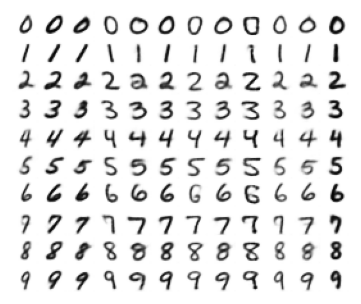

In [26]:
# A first look at conditional sampling from the seed-0 model: rows are the digits 0 to 9 and
# each column is one latent code from N(0, I), decoded under every class.
_ = model.load_state_dict(checkpoint["seed_0"])
z_grid = torch.randn(12, Z_DIM, generator=torch.Generator().manual_seed(SEED)).to(device)
images, _ = sample_grid(model, z_grid)
fig, ax = plt.subplots(figsize=(4.4, 3.8))
ax.imshow(make_grid(images, nrow=12, pad_value=1)[0], cmap="gray", vmin=0, vmax=1)
ax.axis("off")
plt.show()

### 7.1 Where real digits sit in the latent space

Sampling assumes the codes of real digits look like draws from N(0, I). A draw from a
7-dimensional standard normal lies about 2.55 from the origin on average. If the encoder places real
digits much closer in or further out, samples come from regions the decoder rarely saw, which is one
reason samples can look worse than reconstructions.

In [27]:
# How far from the origin the encoder places real digits, against where sampling looks.
# Samples come from N(0, I); if the codes of real digits sit elsewhere, samples land in
# regions the decoder saw little of during training.
dev_cond = F.one_hot(train_labels[dev_index].to(device), NUM_CLASSES).float()
with torch.no_grad():
    dev_mu, _ = model.encode(train_images[dev_index].to(device), dev_cond)
norm_generator = torch.Generator().manual_seed(SEED)
prior_draws = torch.randn(len(dev_mu), Z_DIM, generator=norm_generator).to(device)
print(f"mean length of mu over development images : {dev_mu.norm(dim=1).mean():.3f}")
print(f"mean length of a draw from N(0, I)       : {prior_draws.norm(dim=1).mean():.3f}")

mean length of mu over development images : 2.293
mean length of a draw from N(0, I)       : 2.550
